# 09 – Customer Segmentation & Lifetime Value (CLV) Modeling
## Business Context
ServiceTitan's contractor customers need to understand *which of their own customers*
are most valuable. The same tools that help ServiceTitan segment contractors can be
embedded in the product to help contractors segment their homeowner customers.

Two interconnected tasks:
1. **CLV Prediction**: how much revenue will this customer generate over the next 2 years?
2. **Behavioral Segmentation**: cluster customers into actionable groups for targeted marketing

Classic marketing framework: **RFM (Recency, Frequency, Monetary)**
- **R**: how recently did they last book a service?
- **F**: how frequently do they book per year?
- **M**: how much do they spend per transaction?

More sophisticated: **Pareto/NBD model** (probabilistic CLV) or **BG/NBD + Gamma-Gamma**.
This notebook implements both the simple RFM approach and a predictive CLV model.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [2]:
# ─── Simulate Contractor's Customer Transaction History ───────────────────────
N_CUSTOMERS = 2000
reference_date = pd.Timestamp('2024-12-31')

# Customer archetypes (hidden — what the clustering should discover)
# 1. High-value regulars: annual maintenance + frequent repairs, high spend
# 2. Occasional emergencies: irregular, moderate spend
# 3. New customers: one or two transactions, unknown trajectory
# 4. Churned: haven't called in >18 months

archetypes = np.random.choice(['regular','occasional','new','churned'], N_CUSTOMERS,
                               p=[0.20, 0.35, 0.25, 0.20])

recency_days, frequency, monetary, customer_age_days = [], [], [], []

for arch in archetypes:
    if arch == 'regular':
        r = np.random.randint(10, 90)
        f = np.random.uniform(2.0, 5.0)
        m = np.random.normal(350, 80)
        a = np.random.randint(365, 1825)
    elif arch == 'occasional':
        r = np.random.randint(60, 365)
        f = np.random.uniform(0.5, 1.5)
        m = np.random.normal(250, 100)
        a = np.random.randint(180, 1095)
    elif arch == 'new':
        r = np.random.randint(5, 180)
        f = np.random.uniform(0.1, 0.8)
        m = np.random.normal(200, 80)
        a = np.random.randint(30, 365)
    else:  # churned
        r = np.random.randint(400, 900)
        f = np.random.uniform(0.1, 1.0)
        m = np.random.normal(180, 70)
        a = np.random.randint(400, 1825)
    
    recency_days.append(max(1, r))
    frequency.append(max(0.05, f))
    monetary.append(max(20, m))
    customer_age_days.append(a)

# True CLV (unobserved; what we want to predict)
# Future value is driven by frequency, spend, and likelihood of staying
future_clv = (
    np.array(frequency) * np.array(monetary) * 1.8  # expected 2 years
    * (1 / (1 + 0.001 * np.array(recency_days)))    # penalize recency
    + np.random.normal(0, 80, N_CUSTOMERS)
).clip(0)

df_customers = pd.DataFrame({
    'recency_days':      recency_days,
    'frequency_per_yr':  frequency,
    'avg_transaction':   [round(m, 2) for m in monetary],
    'customer_age_days': customer_age_days,
    'archetype':         archetypes,
    'future_clv_2yr':    future_clv.round(2)
})

print(f"Customer dataset: {df_customers.shape}")
print("\nArchetype distribution:")
print(df_customers['archetype'].value_counts())
print("\nCLV stats by archetype:")
print(df_customers.groupby('archetype')['future_clv_2yr'].agg(['mean','median']).round(2))


Customer dataset: (2000, 6)

Archetype distribution:
archetype
occasional    661
new           508
regular       428
churned       403
Name: count, dtype: int64

CLV stats by archetype:
               mean   median
archetype                   
churned      112.84    98.90
new          149.81   135.96
occasional   366.61   344.54
regular     2116.01  2068.60


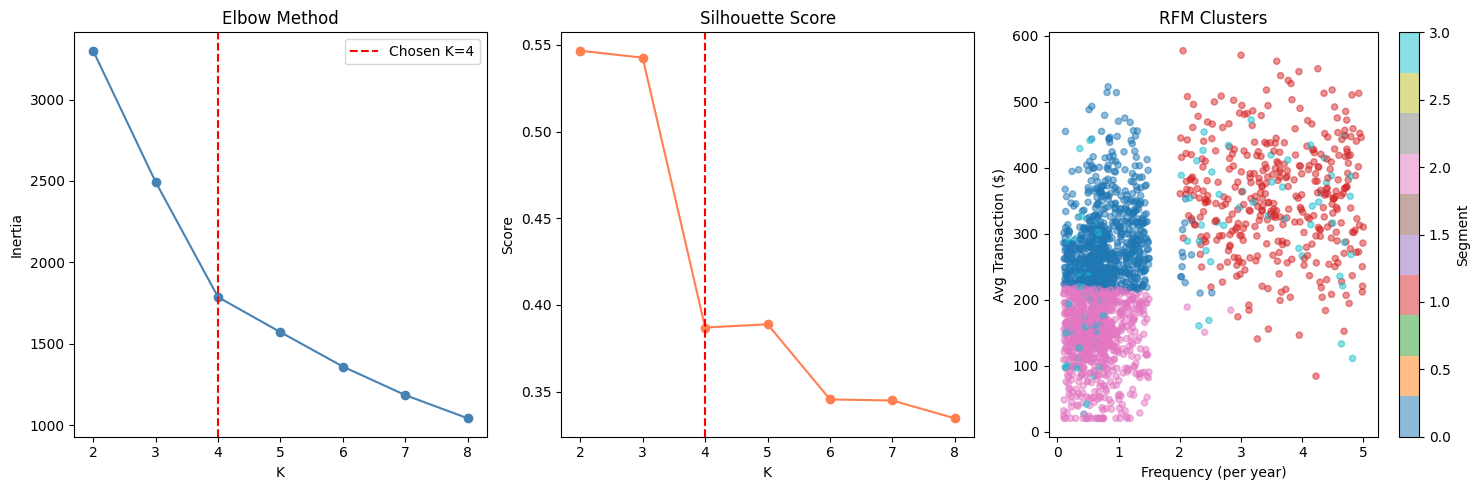

In [3]:
# ─── RFM Segmentation with K-Means ────────────────────────────────────────────
# RFM scores: normalize and cluster customers in 3D space

rfm = df_customers[['recency_days','frequency_per_yr','avg_transaction']].copy()
# Note: lower recency = better, so we invert it
rfm['recency_score'] = 1 / (rfm['recency_days'] + 1)

X_rfm = rfm[['recency_score','frequency_per_yr','avg_transaction']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rfm)

# Find optimal K using elbow + silhouette
inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(K_range, inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].axvline(4, color='red', linestyle='--', label='Chosen K=4'); axes[0].legend()

axes[1].plot(K_range, silhouettes, 'o-', color='coral')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('K'); axes[1].set_ylabel('Score')
axes[1].axvline(4, color='red', linestyle='--')

# Final clustering with K=4
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_customers['segment'] = km4.fit_predict(X_scaled)

# Scatter: frequency vs. monetary, colored by segment
scatter = axes[2].scatter(df_customers['frequency_per_yr'],
                           df_customers['avg_transaction'],
                           c=df_customers['segment'], cmap='tab10', alpha=0.5, s=20)
axes[2].set_title('RFM Clusters'); axes[2].set_xlabel('Frequency (per year)')
axes[2].set_ylabel('Avg Transaction ($)')
plt.colorbar(scatter, ax=axes[2], label='Segment')

plt.tight_layout()
plt.savefig('segmentation.png', dpi=100, bbox_inches='tight')
plt.show()


In [4]:
# ─── Segment Profiling ─────────────────────────────────────────────────────────
segment_profile = (df_customers.groupby('segment')
                   .agg(n_customers=('recency_days','count'),
                        avg_recency=('recency_days','mean'),
                        avg_frequency=('frequency_per_yr','mean'),
                        avg_spend=('avg_transaction','mean'),
                        avg_clv=('future_clv_2yr','mean'))
                   .round(2))
print("=== Segment Profiles ===")
print(segment_profile)

# Label segments meaningfully
segment_names = {}
for seg, row in segment_profile.iterrows():
    if row['avg_frequency'] > 2.5 and row['avg_recency'] < 100:
        segment_names[seg] = 'Champions (High-Value Regulars)'
    elif row['avg_recency'] > 300:
        segment_names[seg] = 'At-Risk / Churned'
    elif row['avg_frequency'] < 0.8:
        segment_names[seg] = 'Occasional / Low Frequency'
    else:
        segment_names[seg] = 'Potential (Growing)'

df_customers['segment_name'] = df_customers['segment'].map(segment_names)
print("\nSegment labels:")
for k, v in segment_names.items():
    print(f"  Segment {k}: {v}")


=== Segment Profiles ===
         n_customers  avg_recency  avg_frequency  avg_spend  avg_clv
segment                                                             
0                731       258.53           0.81     289.25   351.44
1                365        54.06           3.59     355.42  2177.34
2                803       325.17           0.65     145.71   141.31
3                101        14.64           1.88     259.71  1034.23

Segment labels:
  Segment 0: Potential (Growing)
  Segment 1: Champions (High-Value Regulars)
  Segment 2: At-Risk / Churned
  Segment 3: Potential (Growing)


CLV Model MAE:  $70.83
CLV Model R²:   0.989


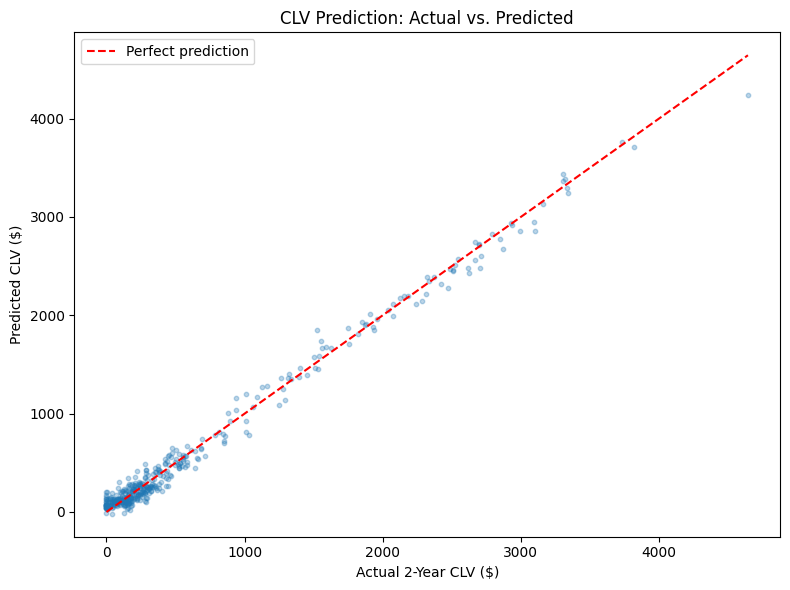

In [5]:
# ─── Predictive CLV Model ─────────────────────────────────────────────────────
# Predict 2-year future CLV from current RFM features
# This enables: "how much should we spend to acquire/retain this customer?"

X_clv = df_customers[['recency_days','frequency_per_yr','avg_transaction','customer_age_days']]
y_clv = df_customers['future_clv_2yr']

X_tr, X_te, y_tr, y_te = train_test_split(X_clv, y_clv, test_size=0.2, random_state=42)

from sklearn.ensemble import GradientBoostingRegressor
clv_model = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                       learning_rate=0.05, random_state=42)
clv_model.fit(X_tr, y_tr)
clv_preds = clv_model.predict(X_te)

from sklearn.metrics import mean_absolute_error, r2_score
print(f"CLV Model MAE:  ${mean_absolute_error(y_te, clv_preds):.2f}")
print(f"CLV Model R²:   {r2_score(y_te, clv_preds):.3f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_te, clv_preds, alpha=0.3, s=10)
ax.plot([0, y_te.max()], [0, y_te.max()], 'r--', label='Perfect prediction')
ax.set_title('CLV Prediction: Actual vs. Predicted')
ax.set_xlabel('Actual 2-Year CLV ($)'); ax.set_ylabel('Predicted CLV ($)')
ax.legend()
plt.tight_layout()
plt.savefig('clv_prediction.png', dpi=100, bbox_inches='tight')
plt.show()


## Key Takeaways for Interview

1. **RFM is the lingua franca of marketing analytics** — product, sales, and business teams understand it intuitively
2. **Silhouette score > inertia** for choosing K — elbow is subjective, silhouette is objective
3. **Segment names matter for adoption**: "Champions" and "At-Risk" are acted on; "Segment 2" is not
4. **CLV enables acquisition budget decisions**: if a Champion CLV = $2,000, spending $200 to acquire one is 10x ROI
5. **Segment membership should update monthly** as customer behavior changes
6. **This same architecture works at ServiceTitan's level** for segmenting contractor accounts, not just homeowner customers
